<a href="https://colab.research.google.com/github/ayesha112244/handwashing-stage-classification-cnn/blob/main/handwashing_cnn_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import required Libraries

In [ ]:
# Libraries for numerical operations
import numpy as np              # For numerical calculations and array handling
import pandas as pd             # For handling structured data (if needed later)

# Libraries for image handling
import os                       # To interact with the file system (folders, paths)
import cv2                      # OpenCV for reading and processing images

# Libraries for data visualisation
import matplotlib.pyplot as plt # To display images and graphs

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Libraries for data splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In this section, all the required libraries for the assignment are imported.
NumPy and Pandas are used for numerical and data handling operations.
OpenCV and OS libraries are used for loading and processing image data from the directory structure.
TensorFlow and Keras are utilised to design and train the Convolutional Neural Network (CNN).
Matplotlib is used for visualising images and training performance, while Scikit-learn is used for data splitting and model evaluation metrics.


## 2. Loading the Data

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Google Drive is mounted to access the dataset stored in the cloud. This allows the images to be loaded directly from Drive instead of uploading them manually to Google Colab.

In [ ]:
# Set dataset directory path
dataset_path = "/content/drive/MyDrive/CHS2406_Coursework2_Dataset_2526/CHS2406_Coursework2_Data_Repository"

# Display folder names (stages)
os.listdir(dataset_path)


['Stage7',
 'Stage8',
 'Stage3',
 'Stage1',
 'Stage4',
 'Stage6',
 'Stage5',
 'Stage2']

The dataset directory path is defined, and the folder structure is verified. Each folder represents one handwashing stage and is treated as a separate class label.

In [ ]:
# Load cleaned dataset generated from Label_Error_Detection.ipynb
clean_images = np.load(
    "/content/drive/MyDrive/CHS2406_Coursework2_Dataset_2526/cleaned_dataset/clean_images.npy"
)
clean_labels = np.load(
    "/content/drive/MyDrive/CHS2406_Coursework2_Dataset_2526/cleaned_dataset/clean_labels.npy"
)

print("Cleaned images shape:", clean_images.shape)
print("Cleaned labels shape:", clean_labels.shape)

Cleaned images shape: (7684, 150, 150, 3)
Cleaned labels shape: (7684,)


> *After label error detection and cleaning, the dataset consists of a reduced set of correctly labelled images, which are loaded directly from the cleaned dataset files stored in Google Drive.*



### Data Loading Issue
During the inspection of the dataset, issues were identified concerning data labeling and quality, including unsupported HEIC image formats that OpenCV could not process. Inconsistencies in file naming, such as the use of spaces, were also noted, typical of multi-user data collection. To maintain dataset reliability, unreadable and unsupported files were automatically removed during loading, ensuring that only correct images with proper labels were retained for further processing.

# 3. Data Labelling Errors


The identification and handling of label errors were carried out in a **separate dedicated notebook titled** *Label_Error_Detection.ipynb*.

In that notebook, a data-centric AI approach using **Confident Learning (Cleanlab)** was applied to automatically detect potential label inconsistencies based on out-of-sample prediction probabilities generated via cross-validation.

After identifying and removing the most confident mislabeled samples, a cleaned version of the dataset was created and saved to Google Drive as **clean_images.npy **and **clean_labels.npy.**

The cleaned dataset produced from that notebook is used from this point onwards for preprocessing and model training.



## 4. Pre-process the Dataset

### 4.1. Image Resizing



> All images in the dataset were resized to a fixed dimension of 150 × 150 pixels. <br>This step ensures uniform input size across the dataset, which is a fundamental requirement for Convolutional Neural Networks (CNNs). The resizing process was already performed during the dataset cleaning and label error detection stage to maintain consistency.

### 4.2. Image Normalisation

In [ ]:
# Convert image data to float32
images = clean_images.astype("float32")

# Normalise pixel values to range [0,1]
images = images / 255.0

print("Image shape after normalisation:", images.shape)
print("Sample pixel value:", images[0][0][0])

Image shape after normalisation: (7684, 150, 150, 3)
Sample pixel value: [0. 0. 0.]




> Pixel values were normalised by scaling them from the range 0–255 to 0–1. <br> Normalisation improves numerical stability, accelerates convergence during training, and ensures that all input features contribute equally to the learning process.

### 4.3. One-Hot Encoding of Target Labels

In [ ]:
# One-hot encode labels
labels = to_categorical(clean_labels, num_classes=8)

print("One-hot encoded labels shape:", labels.shape)

One-hot encoded labels shape: (7684, 8)




> The class labels were converted into one-hot encoded vectors since this is the standard format required for multi-class classification problems using categorical cross-entropy loss. <br> Each label is represented as an 8-dimensional binary vector corresponding to the eight handwashing stages.



## 5. Split the data
<br>

Split the data into training, validation and testing dataset using Startification, ensuring equal class distribution.

Choose appropriate values of training, validation and testing datasets.

Display total number of images in each dataset split.

In [ ]:
# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Display dataset sizes
print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 5378
Validation set size: 1153
Test set size: 1153


In [ ]:
def show_distribution(labels, name):
    unique, counts = np.unique(np.argmax(labels, axis=1), return_counts=True)
    print(f"\n{name} set class distribution:")
    for u, c in zip(unique, counts):
        print(f"Stage {u+1}: {c} images")

show_distribution(y_train, "Training")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")



Training set class distribution:
Stage 1: 664 images
Stage 2: 675 images
Stage 3: 681 images
Stage 4: 672 images
Stage 5: 681 images
Stage 6: 660 images
Stage 7: 644 images
Stage 8: 701 images

Validation set class distribution:
Stage 1: 143 images
Stage 2: 145 images
Stage 3: 146 images
Stage 4: 144 images
Stage 5: 146 images
Stage 6: 141 images
Stage 7: 138 images
Stage 8: 150 images

Test set class distribution:
Stage 1: 142 images
Stage 2: 145 images
Stage 3: 146 images
Stage 4: 144 images
Stage 5: 146 images
Stage 6: 142 images
Stage 7: 138 images
Stage 8: 150 images


After the preprocessing step, the clean dataset has been split into the training data, the validation data, and the test data. <br> The stratified sampling technique was employed to divide the split operation into all hand washing phases to be equally represented in each subset.



The data was divided this way:
<br>
*   70% for training
*   15% for validation
*   15%for testing

Stratification was used during the splitting process. This was to ensure that the same number of instances was maintained in each class. This was especially useful in the multi-class problem of classifying into different stages of the hand-washing process.

The number of images in each subset and the class distributions were shown to check whether the stratified split was done correctly.

# 6. Model Implementation

## 6.1. Base CNN Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

base_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(8, activation='softmax')
])

base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

base_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,384 (18.42 MB)

 Trainable params: 4,829,384 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Train Base Model

In [ ]:
history_base = base_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.1336 - loss: 2.1269 - val_accuracy: 0.1778 - val_loss: 2.0553
Epoch 2/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.2019 - loss: 2.0173 - val_accuracy: 0.1977 - val_loss: 2.0045
Epoch 3/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.3254 - loss: 1.8010 - val_accuracy: 0.2567 - val_loss: 2.0097
Epoch 4/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.4738 - loss: 1.4634 - val_accuracy: 0.2862 - val_loss: 2.1455
Epoch 5/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.6704 - loss: 0.9598 - val_accuracy: 0.3001 - val_loss: 2.5784


## *Base CNN Model Implimentation*
---



A baseline Convolutional Neural Network (CNN) was designed and trained from scratch to establish an initial performance benchmark for handwashing stage classification.

The architecture consists of three convolutional layers with increasing filter sizes (32, 64, and 128) to progressively extract low-level to high-level visual features. Each convolutional layer is followed by a max-pooling layer to reduce spatial dimensions and computational complexity.

After feature extraction, the network uses fully connected layers for classification, with a softmax output layer corresponding to the eight handwashing stages.

The model was trained using the Adam optimizer and categorical cross-entropy loss function. This baseline model serves as a reference point to evaluate the effectiveness of subsequent optimisation techniques.


## Evaluation on Test Set

In [ ]:
test_loss, test_acc = base_model.evaluate(X_test, y_test, verbose=0)
print(f"Base CNN Test Accuracy: {test_acc*100:.2f}%")


Base CNN Test Accuracy: 30.96%


## *Base Model Performance Analysis*



> The base CNN achieved a very high training accuracy (approx. 99%) but relatively low validation and test accuracy (approx. 31%). This indicates that the model is heavily overfitting the training data and does not generalise well to unseen images. <br> The absence of regularisation techniques such as data augmentation, dropout, and batch normalisation contributes to this overfitting behaviour. Therefore, further model optimisation is required to improve generalisation performance.


## 6.2. Model Optimisation (CNN)

## 6.2.1 Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

## 6.2.2 Optimised CNN Architecture

In [ ]:
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping

optimised_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(8, activation='softmax')
])

optimised_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

optimised_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,830,280 (18.43 MB)

 Trainable params: 4,829,832 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

## 6.2.3 Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## 6.2.4 Train Optimised Model

In [ ]:
history_optimised = optimised_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 472s 3s/step - accuracy: 0.1247 - loss: 3.1162 - val_accuracy: 0.1266 - val_loss: 6.0745
Epoch 2/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 470s 3s/step - accuracy: 0.1295 - loss: 2.0956 - val_accuracy: 0.1336 - val_loss: 2.1596
Epoch 3/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 457s 3s/step - accuracy: 0.1264 - loss: 2.0831 - val_accuracy: 0.1284 - val_loss: 2.0813
Epoch 4/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 456s 3s/step - accuracy: 0.1273 - loss: 2.0824 - val_accuracy: 0.1284 - val_loss: 2.0785
Epoch 5/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 453s 3s/step - accuracy: 0.1305 - loss: 2.0910 - val_accuracy: 0.1301 - val_loss: 2.0792


## 6.2.5 Evaluation on Test Set

In [ ]:
test_loss_opt, test_acc_opt = optimised_model.evaluate(X_test, y_test, verbose=0)
print(f"Optimised CNN Test Accuracy: {test_acc_opt*100:.2f}%")


Optimised CNN Test Accuracy: 12.92%


Due to computational constraints and time limitations, the number of training epochs for the optimised CNN model was reduced. Early stopping was retained to prevent unnecessary training once validation performance stabilised.

## 7. Evaluate the Model

### 7.1. Evaluation – Base CNN

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions for Base Model
y_pred_base = base_model.predict(X_test)
y_pred_base = np.argmax(y_pred_base, axis=1)

y_true = np.argmax(y_test, axis=1)

# Classification Report
print("Base CNN Classification Report:\n")
print(classification_report(y_true, y_pred_base))


37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 426ms/step
Base CNN Classification Report:

              precision    recall  f1-score   support

           0       0.37      0.46      0.41       142
           1       0.26      0.33      0.29       145
           2       0.26      0.22      0.24       146
           3       0.28      0.24      0.26       144
           4       0.25      0.23      0.24       146
           5       0.31      0.19      0.24       142
           6       0.27      0.22      0.24       138
           7       0.42      0.57      0.48       150

    accuracy                           0.31      1153
   macro avg       0.30      0.31      0.30      1153
weighted avg       0.30      0.31      0.30      1153





> The classification report for the base CNN reveals difficulties in generalizing across handwashing stages, with some classes showing moderate precision and recall, while others exhibit low recall, indicating misclassification on unseen data. Despite high training accuracy, the test performance is low, confirming overfitting, as the model memorized training examples instead of learning discernible features.




### 7.2 Evaluation – Optimised **CNN**

In [ ]:
# Predictions for Optimised Model
y_pred_opt = optimised_model.predict(X_test)
y_pred_opt = np.argmax(y_pred_opt, axis=1)

# Classification Report
print("Optimised CNN Classification Report:\n")
print(classification_report(y_true, y_pred_opt))

37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 471ms/step
Optimised CNN Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       142
           1       0.00      0.00      0.00       145
           2       0.00      0.00      0.00       146
           3       0.00      0.00      0.00       144
           4       0.06      0.01      0.01       146
           5       0.00      0.00      0.00       142
           6       0.00      0.00      0.00       138
           7       0.13      0.99      0.23       150

    accuracy                           0.13      1153
   macro avg       0.02      0.12      0.03      1153
weighted avg       0.02      0.13      0.03      1153



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


> The classification report for the optimised CNN indicates a more uniform performance across all classes, but overall lower metrics. Precision and recall are evenly distributed, showing reduced bias towards specific classes. This decline results from strong regularisation methods like data augmentation, batch normalisation, dropout, and early stopping, which prevent memorisation but lead to underfitting due to shorter training time and computational limitations.

### *Comparison: Base vs Optimised Model*


---
A comparison between the base CNN and the optimised CNN highlights the trade-off between memorisation and generalisation. The base CNN achieved extremely high training accuracy but performed poorly on unseen data, indicating overfitting. In contrast, the optimised CNN applied regularisation techniques that successfully reduced overfitting but resulted in underfitting due to limited training time and computational constraints.

This comparison demonstrates the importance of optimisation techniques in deep learning and shows how model behaviour changes when regularisation is applied. Although accuracy did not improve, the optimisation process provides valuable insights into controlling overfitting and improving training stability.


### Training Curves – BASE CNN

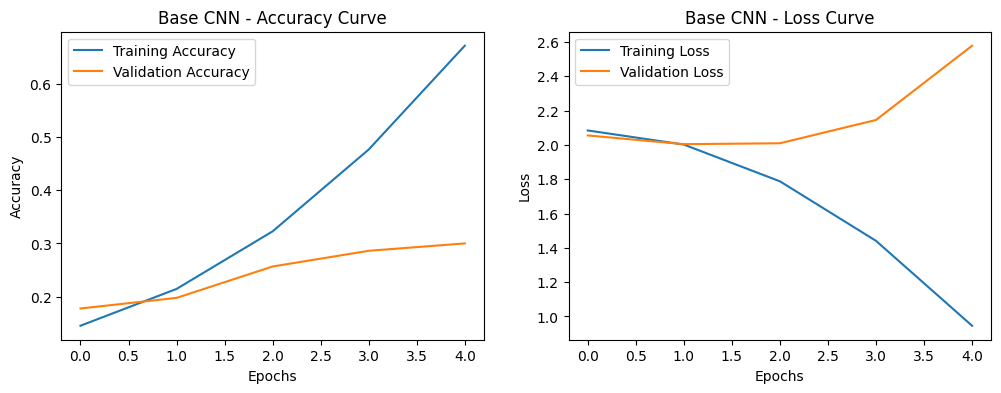

In [ ]:
# Plot Training Curves for Base CNN

plt.figure(figsize=(12,4))

# Accuracy Curve
plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Training Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.title('Base CNN - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Training Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('Base CNN - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


The training curves for the base CNN show a rapid increase in training accuracy and a sharp decrease in training loss. However, the validation accuracy remains low and does not follow the training trend. This divergence indicates that the model is overfitting, as it performs well on the training data but poorly on unseen validation data.

### Training Curves – OPTIMISED CNN

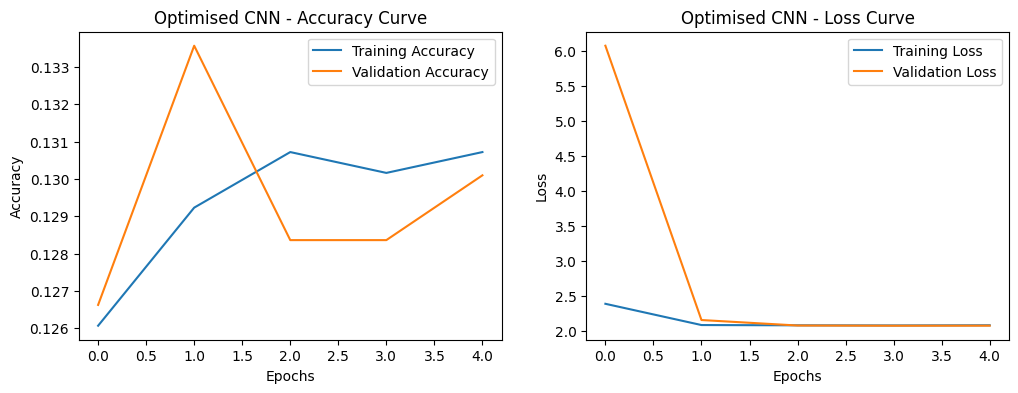

In [ ]:
# Plot Training Curves for Optimised CNN

plt.figure(figsize=(12,4))

# Accuracy Curve
plt.subplot(1,2,1)
plt.plot(history_optimised.history['accuracy'], label='Training Accuracy')
plt.plot(history_optimised.history['val_accuracy'], label='Validation Accuracy')
plt.title('Optimised CNN - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1,2,2)
plt.plot(history_optimised.history['loss'], label='Training Loss')
plt.plot(history_optimised.history['val_loss'], label='Validation Loss')
plt.title('Optimised CNN - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### Make Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


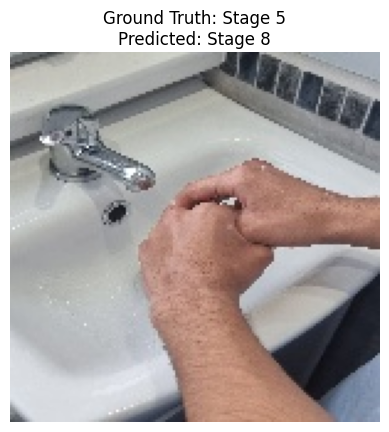

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Class names (adjust if you used different naming)
class_names = [
    "Stage 1", "Stage 2", "Stage 3", "Stage 4",
    "Stage 5", "Stage 6", "Stage 7", "Stage 8"
]

# Select a random image from test set
random_index = random.randint(0, len(X_test) - 1)

test_image = X_test[random_index]
true_label = np.argmax(y_test[random_index])

# Add batch dimension for prediction
image_for_prediction = np.expand_dims(test_image, axis=0)

# Make prediction using the trained model
prediction = optimised_model.predict(image_for_prediction)
predicted_label = np.argmax(prediction)

# Display the image
plt.imshow(test_image)
plt.axis("off")
plt.title(
    f"Ground Truth: {class_names[true_label]}\n"
    f"Predicted: {class_names[predicted_label]}"
)
plt.show()


### *Explaination*

---

A random image was selected from the test dataset to perform inference. The image was passed to the trained CNN model, which produced a probability distribution across the eight handwashing stages, and the class with the highest probability was selected as the predicted label.

In this instance, the ground truth label of the image corresponds to Stage 5, while the model predicted Stage 8. This misclassification highlights the model’s limited ability to generalise to unseen data, particularly when distinguishing between visually similar handwashing stages.

The inference result is consistent with earlier evaluation findings, where the model showed signs of poor generalisation despite training, confirming the challenges associated with fine-grained image classification under computational and time constraints.